In [1]:
import geopandas as gpd

states = gpd.read_file(r"C:\Users\asinha\Coding_KAI\TRB_Paper_Sideswipe\Code\tiger_states\cb_2023_us_state_20m\cb_2023_us_state_20m.shp").to_crs("EPSG:4326")
state_to_analyze = "PA"  # Change to "Maryland" if needed
maryland = states[states["STUSPS"] == state_to_analyze]
maryland_geom = maryland.geometry.values[0]

In [2]:
from ohsome import OhsomeClient
from shapely.geometry import shape
import geopandas as gpd
import ohsome

# Ohsome client
client = ohsome.OhsomeClient()

# Query bike-related tags in Maryland
# query_filter = "highway=* and (cycleway=* or bicycle=designated)"

query_filter = (
    "highway in (primary, secondary, tertiary, residential, unclassified, service) and "
    "(cycleway in (lane, track, opposite_lane, opposite_track) or "
    "cycleway:left in (lane, track, opposite_lane) or "
    "cycleway:right in (lane, track, opposite_track))"
)

# List of years
dates = ["2018-01-01", "2023-01-01"]

results = {}
for date in dates:
    response = client.elements.geometry.post(
        bpolys=maryland.geometry.to_json(),
        time=date,
        filter=query_filter,
        properties="tags"
    )
    geojson = response.data  # ✅ This is where the GeoJSON is stored
    gdf = gpd.GeoDataFrame.from_features(geojson["features"])
    results[date] = gdf

In [3]:
import pandas as pd

# --- Extract from dictionary ---
gdf_2018 = results["2018-01-01"]
gdf_2023 = results["2023-01-01"]

road_highways = [
    "residential", "primary", "secondary", "tertiary",
    "unclassified", "service", "living_street", "trunk"
]

# Only keep ways that are roads
gdf_2018 = gdf_2018[gdf_2018["highway"].isin(road_highways)].copy()
gdf_2023 = gdf_2023[gdf_2023["highway"].isin(road_highways)].copy()

# --- Drop null geometries ---
gdf_2018 = gdf_2018[gdf_2018.geometry.notnull()].copy()
gdf_2023 = gdf_2023[gdf_2023.geometry.notnull()].copy()

# --- Ensure WGS84 CRS before reprojection ---
gdf_2018.set_crs("EPSG:4326", inplace=True)
gdf_2023.set_crs("EPSG:4326", inplace=True)

# --- Reproject to UTM for spatial operations ---
gdf_2018 = gdf_2018.to_crs(epsg=32618)
gdf_2023 = gdf_2023.to_crs(epsg=32618)

# --- Find segments present in 2023 but NOT in 2018 → Added bike lanes ---
new_bikelanes = gpd.sjoin(
    gdf_2023, gdf_2018, how="left", predicate='intersects', lsuffix='2023', rsuffix='2018'
)
new_bikelanes = new_bikelanes[new_bikelanes["index_2018"].isna()].copy()
new_bikelanes["change"] = "Added"

# --- Find segments present in 2018 but NOT in 2023 → Removed bike lanes ---
removed_bikelanes = gpd.sjoin(
    gdf_2018, gdf_2023, how="left", predicate='intersects', lsuffix='2018', rsuffix='2023'
)
removed_bikelanes = removed_bikelanes[removed_bikelanes["index_2023"].isna()].copy()
removed_bikelanes["change"] = "Removed"

# --- Combine results & reproject to WGS84 ---
changes = pd.concat([new_bikelanes, removed_bikelanes], ignore_index=True)
changes = changes.to_crs("EPSG:4326")

# --- Save as GeoJSON ---
changes.to_file(f"bike_lane_changes_{state_to_analyze}.geojson", driver="GeoJSON")
print(f"✅ Exported: 'bike_lane_changes_{state_to_analyze}.geojson'")

✅ Exported: 'bike_lane_changes_PA.geojson'


C:\Users\asinha\AppData\Local\Temp\ipykernel_17108\863541560.py:11: UserWarning: Geometry column does not contain geometry.
  gdf_csv["geometry"] = gdf_csv["geometry"].apply(lambda x: x.wkt)


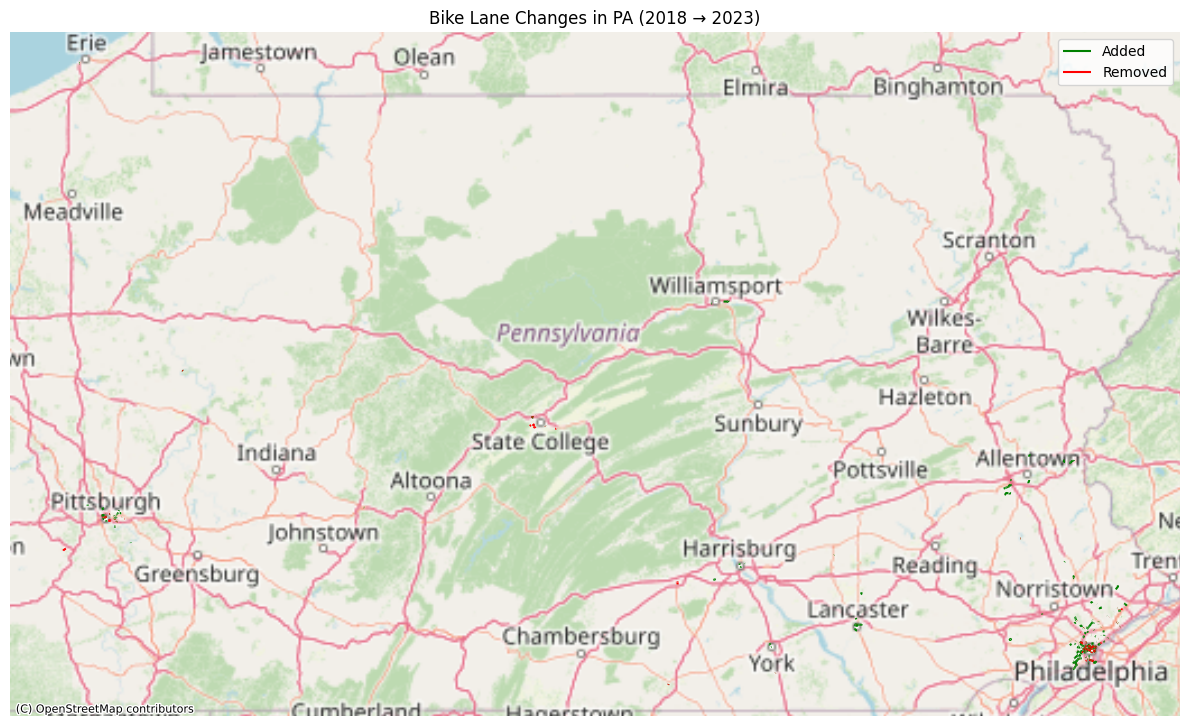

              road_name  change_count
0   Lindbergh Boulevard            83
1  Spring Garden Street            82
2         Island Avenue            32
3      Haverford Avenue            30
4           Waddle Road            29
5         Packer Avenue            28
6    Hamilton Boulevard            27
7     North Krocks Road            26
8       Chestnut Street            25
9         Market Street            21


In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# Load the GeoJSON file
gdf = gpd.read_file(f"bike_lane_changes_{state_to_analyze}.geojson")

# Export as CSV
gdf_csv = gdf.copy()
gdf_csv["geometry"] = gdf_csv["geometry"].apply(lambda x: x.wkt)
gdf_csv.to_csv(f"bike_lane_changes_{state_to_analyze}.csv", index=False)

# Reproject for cleaner plotting
gdf = gdf.to_crs(epsg=3857)

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
gdf[gdf["change"] == "Added"].plot(ax=ax, color="green", label="Added")
gdf[gdf["change"] == "Removed"].plot(ax=ax, color="red", label="Removed")

# Add basemap tiles (OpenStreetMap by default)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title(f"Bike Lane Changes in {state_to_analyze} (2018 → 2023)")
ax.legend()
plt.axis("off")
plt.tight_layout()
plt.show()

# Road-level stats
gdf["road_name"] = gdf["name_2023"].fillna(gdf["name_2018"])
road_stats = gdf["road_name"].value_counts().reset_index()
road_stats.columns = ["road_name", "change_count"]
print(road_stats.head(10))

In [5]:
import geopandas as gpd
import pandas as pd


# Load the changes GeoJSON and ensure WGS84
gdf = gpd.read_file(f"bike_lane_changes_{state_to_analyze}.geojson").to_crs(epsg=4326)

# Use representative point (centroid sometimes fails for very long segments)
gdf["geometry_point"] = gdf.geometry.representative_point()

# Extract lat/lon
gdf["lat"] = gdf.geometry_point.y
gdf["lon"] = gdf.geometry_point.x

# Select relevant columns (add/remove as needed)
columns = [
    "lat", "lon", "change", "name_2023", "name_2018",
    "cycleway_2023", "cycleway_2018", "highway_2023", "highway_2018",
    "lanes_2023", "lanes_2018", "@snapshotTimestamp_2023", "@snapshotTimestamp_2018"
]

# Filter to available columns
columns = [c for c in columns if c in gdf.columns]

# Save to CSV
gdf[columns].to_csv(f"bike_lane_change_points_summary_{state_to_analyze}.csv", index=False)
print(f"✅ Saved as: 'bike_lane_change_points_summary_{state_to_analyze}.csv'")

✅ Saved as: 'bike_lane_change_points_summary_PA.csv'


### get the Nodes and Edges from OSM

In [6]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Step 1: Load bike network for Maryland (change location if needed)
location = "Philadelphia, Pensylvania, USA"  # Change to "Baltimore, USA" if needed
print(f"⏳ Downloading bike network for {location}...")
G = ox.graph_from_place(location, network_type="bike")

# Step 2: Project graph to UTM
G_proj = ox.project_graph(G)
proj_crs = G_proj.graph["crs"]

⏳ Downloading bike network for Philadelphia, Pensylvania, USA...


### Extract Bike lane for Intersections with Bike Facility

In [7]:
# # --- Step 3: Extract nodes with attributes ---
# print("✅ Extracting nodes with attributes...")
# nodes_gdf = ox.graph_to_gdfs(G_proj, nodes=True, edges=False)
# nodes_gdf = nodes_gdf.reset_index()  # Ensure osmid is a column
# nodes_gdf = nodes_gdf.to_crs("EPSG:4326")
# nodes_gdf["lat"] = nodes_gdf.geometry.y
# nodes_gdf["lon"] = nodes_gdf.geometry.x

# # --- Step 4: Load your bike lane change segments ---
# print("⏳ Loading bike lane change GeoJSON...")
# changes = gpd.read_file("bike_lane_changes_maryland.geojson")
# if changes.crs is None:
#     changes.set_crs("EPSG:4326", inplace=True)
# else:
#     changes = changes.to_crs("EPSG:4326")

# # --- Step 5: Project both to same CRS ---
# changes_proj = changes.to_crs(proj_crs)
# nodes_proj = nodes_gdf.to_crs(proj_crs)

# # --- Step 6: Buffer changes and find intersecting nodes ---
# print("🔍 Finding nodes near changed bike lanes...")
# buffered_changes = changes_proj.buffer(20)
# matched_nodes = nodes_proj[nodes_proj.intersects(buffered_changes.unary_union)].copy()

# # --- Step 7: Final formatting ---
# matched_nodes = matched_nodes.to_crs("EPSG:4326")
# matched_nodes["lat"] = matched_nodes.geometry.y
# matched_nodes["lon"] = matched_nodes.geometry.x
# matched_nodes["segment_index"] = matched_nodes.index  # Unique identifier for image matching

# # --- Step 8: Save ---
# print("💾 Saving matched intersections...")
# matched_nodes.to_file("changes_in_bike_infra_matched_howard.geojson", driver="GeoJSON")
# matched_nodes[["lat", "lon", "segment_index", "osmid"]].to_csv("changes_in_bike_infra_matched_howard.csv", index=False)
# print("✅ Done: Saved real OSM node IDs for NAIP image download.")

### Extract State Road and Multilane Roads with Bike facility

In [8]:
# Step 2: Extract edges with attributes
edges = ox.graph_to_gdfs(G_proj, nodes=False, edges=True).reset_index()
edges = edges.to_crs("EPSG:4326")
edges["ref"] = edges["ref"].fillna("").astype(str)
edges["lanes"] = pd.to_numeric(edges["lanes"], errors="coerce")

# Step 3: Filter edges for state roads and multi-lane roads
state_roads = edges[edges["ref"].str.contains(r"\bMD[- ]?\d+", regex=True)].copy()
multi_lane_roads = edges[edges["lanes"] >= 2].copy()
combined_roads = gpd.GeoDataFrame(
    pd.concat([state_roads, multi_lane_roads], ignore_index=True)
).drop_duplicates(subset=["geometry"]).set_crs("EPSG:4326").to_crs(proj_crs)

# Step 4: Load bike lane changes
changes = gpd.read_file(f"bike_lane_changes_{state_to_analyze}.geojson")
if changes.crs is None:
    changes.set_crs("EPSG:4326", inplace=True)
changes_proj = changes.to_crs(proj_crs)

# Step 5: Extract and project nodes
nodes_gdf = ox.graph_to_gdfs(G_proj, nodes=True, edges=False).reset_index()
nodes_gdf = nodes_gdf.to_crs(proj_crs)

# Step 6: Match nodes near bike changes
buffered_changes = changes_proj.buffer(20)
matched_nodes = nodes_gdf[nodes_gdf.intersects(buffered_changes.unary_union)].copy()

# Step 7: Filter those nodes intersecting state or multilane roads
buffered_combined = combined_roads.buffer(10)
matched_nodes_combined = matched_nodes[matched_nodes.intersects(buffered_combined.unary_union)].copy()

# Finalize
matched_nodes_combined = matched_nodes_combined.to_crs("EPSG:4326")
matched_nodes_combined["lat"] = matched_nodes_combined.geometry.y
matched_nodes_combined["lon"] = matched_nodes_combined.geometry.x
matched_nodes_combined["segment_index"] = matched_nodes_combined.index

# Save
matched_nodes_combined.to_file("bike_lane_state_or_multilane_philadelphia.geojson", driver="GeoJSON")
matched_nodes_combined[["osmid", "lat", "lon", "segment_index"]].to_csv("bike_lane_state_or_multilane_philadelphia.csv", index=False)
print("✅ Done: Saved real OSM node IDs for NAIP image download for State roads and lane>2.")

C:\Users\asinha\AppData\Local\Temp\ipykernel_17108\825835651.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  matched_nodes = nodes_gdf[nodes_gdf.intersects(buffered_changes.unary_union)].copy()
C:\Users\asinha\AppData\Local\Temp\ipykernel_17108\825835651.py:30: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  matched_nodes_combined = matched_nodes[matched_nodes.intersects(buffered_combined.unary_union)].copy()


✅ Done: Saved real OSM node IDs for NAIP image download for State roads and lane>2.
